In [1]:
# import sys
# sys.path.insert(0, "/home/mlokken/software/pymsz")
import numpy as np
import pymsz
%load_ext autoreload
%autoreload 2

In [2]:
pymsz.__path__

['/cita/h/home-2/mlokken/software/pymsz/pymsz']

In [3]:
CENTER = np.array([500000, 500000, 500000], dtype=np.float32)
EXTRACTION_RADIUS = 20000.0  # kpc
ANGULAR_RESOLUTION = 5 # 30 # arcsec -- this sets the pixel size, not the smoothing. 0.5' is SO-like pixels
NPIXEL = 'auto'# 350*3
NCPU = 8
sim = pymsz.load_data(
            "/mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5", snapshot=True, center=CENTER, radius=EXTRACTION_RADIUS,
            cut_sfr=0.1, restrict_r=False
        )

reading files:  ['/mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5']
Reading /mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5 file with Header


In [4]:
sim.cosmology["z"]

0.9872814067431317

In [5]:
sim.prep_ss_TT()

In [6]:
np.mean(np.log10(sim.electron_number_density))

-4.9757886

In [7]:
np.mean(np.log10(sim.electron_number_density))

-4.9757886

In [8]:
np.log10(sim.electron_temperature)

array([7.78047  , 7.752106 , 7.7635775, ..., 6.0499907, 5.887157 ,
       4.985814 ], dtype=float32)

In [9]:
pj = pymsz.TT_model(
            sim, label='ne', npixel=NPIXEL, axis='z', neighbours=128,
            redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=4,
            sph_kernel='cubic', Memreduce=True
        )

# pj = pymsz.TT_model(
#             sim, label='Te', npixel=NPIXEL, axis='z', neighbours=64,
#             redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=NCPU,
#             sph_kernel='cubic', Memreduce=True
#         )

Convert the neighbor count in pixel size:  32.84226701231143
Init smoothing, RAM=1.556 GB
After cKDTree , RAM=1.738 GB
Directly pass the cKDTree to tasks with Python version 3.10.2 (main, Jan 25 2022, 10:08:04) [GCC 8.5.0 20210514 (Red Hat 8.5.0-4)]


In [15]:
z = sim.cosmology["z"]

In [16]:
z

0.9872814067431317

In [18]:
pj.write_fits_image("/mnt/scratch-lustre/mlokken/agnvar_300/ne_NEW_BH_JET_0kv3_snap_097.fits", overwrite=True,
                                comments=f"Simulation redshift: {z:.2f}")

In [19]:
import functions as func
ymap, xcen, ycen, zcen, pixsize, xmin, xmax, ymin, ymax = func.load_ymap("/mnt/scratch-lustre/mlokken/agnvar_300/ne_NEW_BH_JET_0kv3_snap_097.fits")


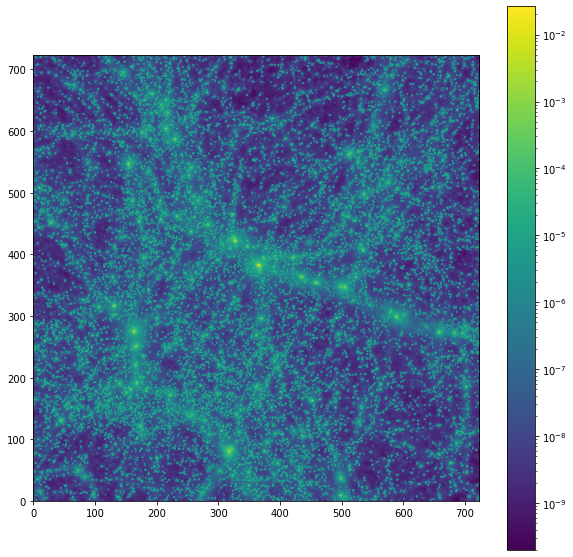

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.figure(figsize=[10,10])
plt.imshow(ymap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar()